# Outbreak Probabilities — End-to-End Pipeline

This is a notebook that runs the whole project: it generates the simulation data, estimates the
probability of a major outbreak (PMO) three ways, trains the ML models, and compares all methods.

| Section | Stage |
|---------|-------|
| 1–4 | Data generation (serial weights → trajectories → `sim_df`) |
| 5   | Trajectory & PMO-vs-R plots |
| 6   | Analytic PMO estimator |
| 7–8 | Trajectory matching + matched-trajectory plot |
| 9   | Cumulative PMO across matches |
| 10  | ML PMO estimator (**trains** RF & GB, convergence plots) |
| 11  | Comparison: ML vs trajectory-matching vs analytic |

This notebook does everything in terms of dataFrames rather than CSVs: paths are saved in one in-memory DataFrame `sim_df`
(with columns `sim_id, sim_seed, R_draw, week_1..k, cumulative_cases, status, PMO`).
Every downstream step consumes that DataFrame directly. This avoids awkward `fillna(-999)` in the original.

## 0. Imports and configuration

In [4]:
import csv
import json
import math
import re
import time
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
from numpy.random import default_rng
from numpy.polynomial.legendre import leggauss

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from scipy.integrate import quad
from scipy.special import gammaln, logsumexp, lambertw
from scipy.stats import gamma as scipy_gamma

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Output directory for saved figures
FIGS_DIR = Path("figs")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Serial-interval defaults (paper-derived)
MEAN_SI_DAYS = 15.3
SD_SI_DAYS = 9.3
DEFAULT_R_MIN = 0.0
DEFAULT_R_MAX = 10.0


def week_cols_of(df: pd.DataFrame, prefix: str = "week_") -> List[str]:
    """Return week_* columns sorted by their numeric suffix."""
    cols = [c for c in df.columns if str(c).startswith(prefix)]
    return sorted(cols, key=lambda s: int(str(s).split(prefix)[1]))


print("Imports ready.")

Imports ready.


## 1. Serial-interval weights

`compute_serial_weights` discretises a continuous gamma serial-interval
distribution into weekly weights `w = [w1, w2, ...]` (triangular kernel +
Gauss–Legendre quadrature), adjusting the first bin so the weights sum to 1.

In [ ]:
@lru_cache(maxsize=64)
# LRU cache is fast 
def compute_serial_weights(mean: float, std: float, k_max: int,
                           nquad: int = 64, step: float = 7.0) -> np.ndarray:
    """Weekly serial-interval weights via Gauss-Legendre quadrature (sum to 1)."""
    if not isinstance(k_max, int) or k_max < 1:
        raise ValueError("k_max must be an integer >= 1")
    if mean <= 0.0 or std <= 0.0:
        raise ValueError("mean and std must be positive numbers")

    var = std ** 2
    shape = (mean / std) ** 2
    scale = var / mean
    g = scipy_gamma(a=shape, scale=scale)

    if k_max == 1:
        return np.array([1.0], dtype=float)

    nodes, quad_weights = leggauss(nquad)
    w = np.zeros(k_max, dtype=float)

    for k in range(1, k_max + 1):
        center = step * k
        left = step * (k - 1)
        right = step * (k + 1)
        half_width = 0.5 * (right - left)
        midpoint = 0.5 * (right + left)
        u = half_width * nodes + midpoint

        tri = 1.0 - np.abs(u - center) / step
        tri[tri < 0.0] = 0.0
        pdf_vals = g.pdf(u)
        integrand = tri * pdf_vals
        w[k - 1] = half_width * np.sum(quad_weights * integrand)

    total = float(w.sum())
    if total <= 0.0 or not np.isfinite(total):
        raise RuntimeError("Serial-interval weights sum to non-positive/non-finite value")

    # adjust first bin so sum(w)=1 (Gittins-like adjustment)
    w[0] = max(0.0, 1.0 - w[1:].sum())
    w /= w.sum()
    return w


# quick sanity check
_w_demo = compute_serial_weights(MEAN_SI_DAYS, SD_SI_DAYS, k_max=50)
print(f"For mean: {MEAN_SI_DAYS:.2f}, standard deviation: {SD_SI_DAYS:.2f}")
print("len(w) =", len(_w_demo), "| sum(w) =", _w_demo.sum(), "| w[:5] =", _w_demo[:5])

For mean: 15.30, standard deviation: 9.30
len(w) = 50 | sum(w) = 1.0 | w[:5] = [0.35336988 0.30667046 0.18593784 0.09029724 0.03890884]


## 2. Single-trajectory simulation

`calculate_R` draws a reproduction number; `simulate_trajectory` runs a
Poisson-renewal process week by week, stopping on a major outbreak (cumulative
cases ≥ threshold) or on local extinction.

In [9]:
def calculate_R(R_range, rng=None, dist="uniform", dist_params=None):
    """Draw a single reproduction number R from the requested distribution."""
    if rng is None:
        rng = default_rng()
    rmin, rmax = float(R_range[0]), float(R_range[1])
    if rmin == rmax:
        return float(rmin)
    if dist == "uniform":
        return float(rng.uniform(rmin, rmax))
    if dist == "normal":
        params = {} if dist_params is None else dict(dist_params)
        mu = params.get("mean", 0.5 * (rmin + rmax))
        sd = params.get("sd", (rmax - rmin) / 4.0)
        return float(max(rmin, min(rmax, rng.normal(mu, sd))))
    if dist == "lognormal":
        if rmin <= 0:
            raise ValueError("R_range lower bound must be > 0 for lognormal")
        log_min, log_max = np.log(rmin), np.log(rmax)
        return float(np.exp(rng.uniform(log_min, log_max)))
    raise ValueError(f"Unknown dist '{dist}'")


def _is_extinct_window(trajectory, window):
    if not window or window <= 0:
        return False
    if trajectory.size < window:
        return False
    return bool(np.all(trajectory[-window:] == 0))


def simulate_trajectory(w, max_weeks=50, R=None, R_range=None, initial_cases=None,
                        rng=None, extinction_window=None, major_threshold=100,
                        stop_on_major=True):
    """Poisson-renewal single-trajectory simulator.

    Convention: w[0] is the 1-step-lag serial weight (I_{t-1} -> I_t)."""
    if rng is None:
        rng = default_rng()
    w_arr = np.asarray(w, dtype=float)
    if w_arr.ndim != 1:
        raise ValueError("w must be 1-D")
    if max_weeks < 1:
        raise ValueError("max_weeks must be >= 1")

    if R is None:
        if R_range is None:
            raise ValueError("Either R or R_range must be provided")
        R = float(calculate_R(R_range, rng=rng))
    else:
        R = float(R)

    initial = [1] if initial_cases is None else list(initial_cases)

    trajectory = np.zeros(int(max_weeks), dtype=int)
    L = min(len(initial), int(max_weeks))
    trajectory[:L] = np.asarray(initial[:L], dtype=int)
    cumulative = int(trajectory[:L].sum())

    major_flag = cumulative >= major_threshold
    extinct_flag = False
    t_end = L

    for t in range(L, int(max_weeks)):
        max_lag = min(w_arr.size, t)
        if max_lag == 0:
            lam_base = 0.0
        else:
            past = trajectory[t - max_lag : t]
            ws = w_arr[:max_lag]
            lam_base = float(np.dot(ws, past[::-1]))

        lam = R * lam_base
        new_cases = int(rng.poisson(lam)) if lam > 0.0 else 0
        trajectory[t] = new_cases
        cumulative += new_cases
        t_end = t + 1

        if cumulative >= major_threshold:
            major_flag = True
            if stop_on_major:
                break
        if extinction_window is not None and _is_extinct_window(trajectory[: t + 1], extinction_window):
            extinct_flag = True
            break

    if major_flag:
        status, pmo = "major", 1
    elif extinct_flag:
        status, pmo = "minor", 0
    else:
        status, pmo = "ongoing", 0

    return {"trajectory": trajectory, "R": R, "cumulative": cumulative,
            "status": status, "PMO": pmo, "t_end": t_end}

## 3. Batch generation 

`simulate_paths` runs `N` trajectories and returns a tidy **DataFrame** plus the
full `(N, max_weeks)` array and the serial weights.

In [21]:
@dataclass
class SimConfig:
    N: int = 1000
    max_weeks: int = 50
    mean_serial: float = 15.3
    std_serial: float = 9.3
    k_max: int = 50
    nquad: int = 32
    step: float = 7.0
    R_range: Tuple[float, float] = (0.0, 10.0)
    initial_cases: Iterable[int] = (1,)
    extinction_window: int = 10
    major_threshold: int = 100
    seed: Optional[int] = None
    R_dist: str = "uniform"
    R_dist_params: Optional[dict] = None
    write_weeks: int = 5  # number of week_* columns to keep in sim_df


def simulate_paths(cfg: SimConfig) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Simulate cfg.N trajectories.

    Returns (sim_df, trajectories, w):
      - sim_df: one row per simulation with sim_id, sim_seed, R_draw,
        week_1..write_weeks, cumulative_cases, status, PMO (clean dtypes).
      - trajectories: full (N, max_weeks) integer array (zeros after stop).
      - w: serial-interval weights used.
    """
    master_rng = default_rng(cfg.seed)
    R_min, R_max = float(cfg.R_range[0]), float(cfg.R_range[1])

    w = compute_serial_weights(cfg.mean_serial, cfg.std_serial, cfg.k_max, cfg.nquad, cfg.step)
    if len(w) < cfg.max_weeks:
        raise RuntimeError(f"weights length {len(w)} < max_weeks {cfg.max_weeks}; raise k_max.")

    n_write = min(max(1, int(cfg.write_weeks)), cfg.max_weeks)
    trajectories = np.zeros((int(cfg.N), int(cfg.max_weeks)), dtype=int)
    rows = []

    for sim_idx in range(int(cfg.N)):
        sim_seed = int(master_rng.integers(low=0, high=2**63 - 1, dtype=np.int64))
        child_rng = default_rng(sim_seed)
        R = calculate_R((R_min, R_max), rng=child_rng, dist=cfg.R_dist, dist_params=cfg.R_dist_params)

        result = simulate_trajectory(
            w=w, max_weeks=int(cfg.max_weeks), R=R, initial_cases=list(cfg.initial_cases),
            rng=child_rng, extinction_window=cfg.extinction_window,
            major_threshold=cfg.major_threshold)

        traj = np.asarray(result["trajectory"], dtype=int)
        trajectories[sim_idx, :] = traj

        row = {"sim_id": sim_idx + 1, "sim_seed": sim_seed, "R_draw": float(R)}
        for d in range(1, n_write + 1):
            row[f"week_{d}"] = int(traj[d - 1])
        row["cumulative_cases"] = int(result["cumulative"])
        row["status"] = result["status"]
        row["PMO"] = int(result["PMO"])
        rows.append(row)

    sim_df = pd.DataFrame(rows)
    week_cols = [f"week_{d}" for d in range(1, n_write + 1)]
    sim_df[week_cols] = sim_df[week_cols].astype(int)
    sim_df["PMO"] = sim_df["PMO"].astype(int)
    return sim_df, trajectories, w


def export_runner_csv(sim_df: pd.DataFrame, w: np.ndarray, cfg: SimConfig, path: str) -> str:
    """Write a runner.py-compatible CSV (3 metadata rows + header). Optional."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    n_write = sum(c.startswith("week_") for c in sim_df.columns)
    header = list(sim_df.columns)
    hlen = len(header)
    R_min, R_max = float(cfg.R_range[0]), float(cfg.R_range[1])

    def pad(row):
        return (row + [""] * hlen)[:hlen]

    with path.open("w", newline="") as fh:
        writer = csv.writer(fh)
        writer.writerow(pad(["", "w_preview"] + [float(x) for x in w[:n_write]]))
        writer.writerow(pad(["", "R_range", R_min, R_max]))
        writer.writerow(pad(["", "master_seed", cfg.seed]))
        writer.writerow(header)
        sim_df.to_csv(fh, header=False, index=False)

    # sidecar weights JSON (as the original generate_batch produced)
    with path.with_suffix(".weights.json").open("w") as f:
        json.dump({"weights": list(map(float, w)),
                   "metadata": {"k_max": int(len(w)), "step_days": 7.0,
                                "R_range": [R_min, R_max],
                                "major_threshold": cfg.major_threshold,
                                "extinction_window": cfg.extinction_window}}, f, indent=2)
    return str(path)

## 4. Run the simulation

We generate **N = 35,000** trajectories so the downstream matching, PMO-vs-r and
(especially) the ML/comparison sections have enough data — the ML convergence
sweep trains on subsets up to 34,500. Generation is fast (~1–2 s).

In [22]:
sim_cfg = SimConfig(
    N=35000,
    seed=42,
    initial_cases=[1],
    max_weeks=50,
    write_weeks=5,
    major_threshold=100,
    R_range=(0.0, 10.0),
)

_t0 = time.perf_counter()
sim_df, trajectories, w = simulate_paths(sim_cfg)
print(f"Simulated {len(sim_df)} trajectories in {time.perf_counter() - _t0:.2f}s")
print("PMO rate:", sim_df["PMO"].mean().round(4), "| columns:", list(sim_df.columns))

# Optional: also write a runner.py-compatible CSV (nothing below reads it back).
EXPORT_CSV = True
if EXPORT_CSV:
    print("Exported CSV ->", export_runner_csv(sim_df, w, sim_cfg, "data/test_simulations.csv"))

sim_df.head()

Simulated 35000 trajectories in 1.46s
PMO rate: 0.8341 | columns: ['sim_id', 'sim_seed', 'R_draw', 'week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'cumulative_cases', 'status', 'PMO']
Exported CSV -> data/test_simulations.csv


,sim_id,sim_seed,R_draw,week_1,week_2,week_3,week_4,week_5,cumulative_cases,status,PMO
0,1,7138484576005690179,3.060150,1,1,2,4,6,116,major,1
1,2,4047939128787533792,9.312232,1,2,13,45,197,258,major,1
2,3,7919168045412322065,4.543259,1,2,1,6,14,139,major,1
3,4,6432084778622665797,5.772972,1,0,1,4,6,236,major,1
4,5,868632717012091125,0.248666,1,0,0,0,0,1,minor,0


## 5. Plot simulated trajectories

A fast many-line trajectory plot (optional mean / quantile overlays) and a
PMO-vs-R scatter with binned means. All functions take `sim_df` directly.

In [23]:
def compute_binned_pmo(df: pd.DataFrame, n_bins: int = 20) -> pd.DataFrame:
    if "R_draw" not in df.columns or "PMO" not in df.columns:
        raise ValueError("Dataframe must contain 'R_draw' and 'PMO' columns")
    r_min, r_max = df["R_draw"].min(), df["R_draw"].max()
    bins = np.linspace(r_min, r_max, n_bins + 1)
    dfc = df.copy()
    dfc["R_bin"] = pd.cut(dfc["R_draw"], bins=bins, include_lowest=True)
    summary = (dfc.groupby("R_bin", observed=True)
                  .agg(PMO_mean=("PMO", "mean"), count=("PMO", "size"))
                  .reset_index())
    summary["R_mid"] = summary["R_bin"].apply(lambda b: 0.5 * (b.left + b.right))
    return summary


def select_indices(df, week_cols, strategy, sample_size, hybrid_k=25, random_seed=None):
    """Indices to plot per strategy: random/highest_cumulative/highest_peak/highest_R/hybrid."""
    n = len(df)
    rng = np.random.default_rng(random_seed)
    if sample_size is None or sample_size >= n:
        return np.arange(n)
    if strategy == "random":
        return rng.choice(n, size=sample_size, replace=False)

    arr = df[week_cols].to_numpy(dtype=float)
    cumulative = arr.sum(axis=1)
    peak = arr.max(axis=1)
    Rdraw = df["R_draw"].values if "R_draw" in df.columns else np.zeros(n)

    if strategy == "highest_cumulative":
        return np.argsort(-cumulative)[:sample_size]
    if strategy == "highest_peak":
        return np.argsort(-peak)[:sample_size]
    if strategy == "highest_R":
        return np.argsort(-Rdraw)[:sample_size]
    if strategy == "hybrid":
        k = min(hybrid_k, max(1, sample_size // 4))
        idx_set = set(list(np.argsort(-cumulative)[:k])
                      + list(np.argsort(-peak)[:k])
                      + list(np.argsort(-Rdraw)[:k]))
        remaining = sample_size - len(idx_set)
        if remaining > 0:
            pool = np.setdiff1d(np.arange(n), np.fromiter(idx_set, int))
            choice = rng.choice(pool, size=remaining, replace=False)
            idx_set.update(choice.tolist())
        return np.fromiter(sorted(idx_set), dtype=int)
    raise ValueError(f"Unknown sampling strategy: {strategy}")


def mask_after_threshold_array(weeks_arr: np.ndarray, threshold: int) -> np.ndarray:
    """Set values after the first week cumulative>=threshold to NaN (per row)."""
    weeks = weeks_arr.astype(float).copy()
    cumulative = np.cumsum(weeks, axis=1)
    n_sim, n_weeks = weeks.shape
    for i in range(n_sim):
        reached = np.where(cumulative[i, :] >= threshold)[0]
        if reached.size > 0:
            first_idx = int(reached[0])
            if first_idx + 1 < n_weeks:
                weeks[i, first_idx + 1:] = np.nan
    return weeks

In [24]:
def fast_plot_trajectories(df, week_cols=None, save_path="figs/weekly_trajectories.png",
                           sample_strategy="hybrid", sample_size=200, major_threshold=100,
                           overlay_mean=True, overlay_quantiles=(0.10, 0.90),
                           random_seed=42, figsize=(10, 6)):
    """Many-line trajectory plot using LineCollection; saves PNG and shows inline."""
    week_cols = week_cols or week_cols_of(df)
    n_total = len(df)
    if not week_cols:
        raise ValueError("No week columns provided")

    weeks = np.arange(1, len(week_cols) + 1)
    arr = df[week_cols].to_numpy(dtype=float)
    arr_masked = mask_after_threshold_array(arr, major_threshold)

    mean_per_week = np.nanmean(arr_masked, axis=0) if overlay_mean else None
    if overlay_quantiles:
        q_lo = np.nanpercentile(arr_masked, overlay_quantiles[0] * 100, axis=0)
        q_hi = np.nanpercentile(arr_masked, overlay_quantiles[1] * 100, axis=0)
    else:
        q_lo = q_hi = None

    sel_idx = np.unique(select_indices(df, week_cols, strategy=sample_strategy,
                                       sample_size=sample_size, random_seed=random_seed))
    sel_arr = arr[sel_idx, :]

    segs, cutoff_points_x, cutoff_points_y = [], [], []
    for row in sel_arr:
        cumulative = np.cumsum(row)
        hit = np.where(cumulative >= major_threshold)[0]
        if hit.size > 0:
            cutoff = int(hit[0])
            xs, ys = weeks[: cutoff + 1], row[: cutoff + 1]
            segs.append(np.column_stack([xs, ys]))
            cutoff_points_x.append(xs[-1]); cutoff_points_y.append(ys[-1])
        else:
            segs.append(np.column_stack([weeks, row]))

    lc = LineCollection(segs, linewidths=0.9, colors=(0.3, 0.3, 0.3, 0.35), zorder=1)
    fig, ax = plt.subplots(figsize=figsize)
    ax.add_collection(lc)
    ax.autoscale()

    if cutoff_points_x:
        ax.scatter(cutoff_points_x, cutoff_points_y, color="red", s=26, zorder=3,
                   label="first week >= threshold")
    if mean_per_week is not None:
        ax.plot(weeks, mean_per_week, color="#1f77b4", linewidth=2.0, label="mean (masked)")
    if (q_lo is not None) and (q_hi is not None):
        ax.fill_between(weeks, q_lo, q_hi, color="#7f8fa6", alpha=0.25,
                        label=f"{int(overlay_quantiles[0]*100)}-{int(overlay_quantiles[1]*100)}%")

    ax.set_xlabel("Week"); ax.set_ylabel("Cases per week")
    ax.set_title(f"Weekly trajectories (cutoff >= {major_threshold}) "
                 f"- plotted {len(sel_idx)} of {n_total}")
    ax.set_xticks(np.arange(1, len(week_cols) + 1))
    ax.set_xlim(1 - 0.5, len(week_cols) + 0.5)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize="small")
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved fast trajectories plot to {save_path}")


def plot_pmo_vs_R(df, n_bins=20, save_path="figs/pmo_vs_r.png"):
    """PMO-vs-R scatter with binned means; saves PNG and shows inline."""
    binned = compute_binned_pmo(df, n_bins=n_bins)
    fig = plt.figure(figsize=(8, 5))
    jitter = (np.random.rand(len(df)) - 0.5) * 0.02
    plt.scatter(df["R_draw"], df["PMO"] + jitter, alpha=0.25, s=18, label="raw outcomes")
    plt.plot(binned["R_mid"], binned["PMO_mean"], marker="o", linewidth=2, label="binned PMO (mean)")
    plt.xlabel("R"); plt.ylabel("Probability of Major Outbreak (PMO)")
    plt.title("PMO vs R"); plt.ylim(-0.05, 1.05); plt.grid(alpha=0.3); plt.legend()
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved PMO plot to {save_path}")


def run_plotting(df, bins=20, major_threshold=100, sample_strategy="hybrid",
                 sample_size=200, random_seed=42, overlay_mean=True,
                 overlay_quantiles=(0.10, 0.90)):
    week_cols = week_cols_of(df)
    plot_pmo_vs_R(df, n_bins=bins)
    fast_plot_trajectories(df, week_cols, sample_strategy=sample_strategy,
                           sample_size=sample_size, major_threshold=major_threshold,
                           overlay_mean=overlay_mean, overlay_quantiles=overlay_quantiles,
                           random_seed=random_seed)

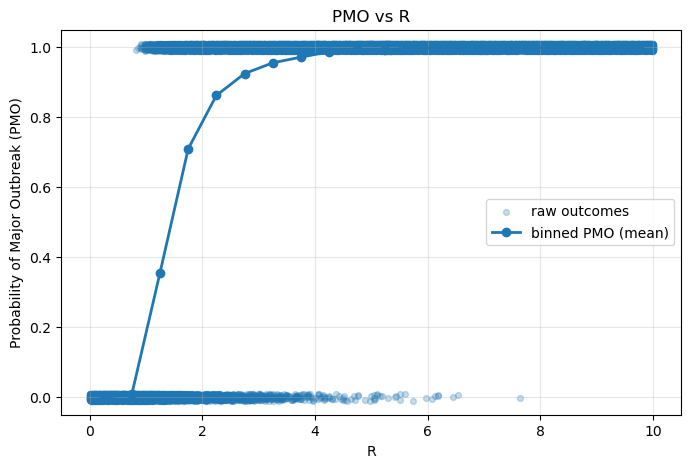

Saved PMO plot to figs/pmo_vs_r.png


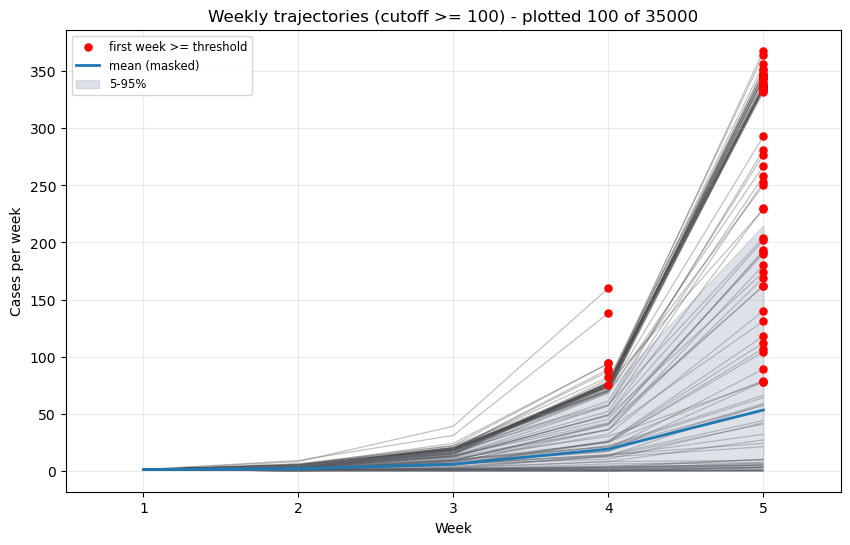

Saved fast trajectories plot to figs/weekly_trajectories.png
Plots written


In [25]:
run_plotting(
    sim_df,
    sample_strategy="hybrid",
    sample_size=100,
    overlay_mean=True,
    overlay_quantiles=(0.05, 0.95),
    bins=20,
    major_threshold=100,
    random_seed=42,
)
print("Plots written")

## 6. Analytic PMO estimator

Given an observed early sequence of weekly counts, integrate the conditional
probability of a major outbreak `PMO(R)` (branching-process theory) over the
posterior of `R` under a Poisson-renewal likelihood with a uniform prior. Uses a
high-precision `quad`-based weekly weight function, independent of the data.

In [26]:
def weekly_w(max_weeks=50, mean=MEAN_SI_DAYS, sd=SD_SI_DAYS):
    """High-precision weekly serial weights via scipy.quad (analytic variant)."""
    shape = (mean / sd) ** 2
    scale = sd ** 2 / mean

    def g(x):
        return scipy_gamma.pdf(x, a=shape, scale=scale)

    w = np.zeros(max_weeks)
    for k in range(1, max_weeks + 1):
        left = max(0.0, 7 * (k - 1))
        right = 7 * (k + 1)

        def integrand(u):
            return (1.0 - abs(u - 7 * k) / 7.0) * g(u) if abs(u - 7 * k) <= 7 else 0.0

        val, _ = quad(integrand, left, right, epsabs=1e-9, epsrel=1e-9)
        w[k - 1] = val

    w[0] = max(0.0, 1.0 - w[1:].sum())
    w /= w.sum()
    return w


def parse_initial_cases(s: str) -> List[int]:
    if not s:
        return []
    toks = [t for t in re.split(r"[,\s;]+", s.strip()) if t]
    return [int(t) for t in toks]


def log_likelihood_I(I_seq: List[int], R: float, w: np.ndarray) -> float:
    """Poisson-renewal log-likelihood of an observed early sequence given R."""
    I = np.asarray(I_seq, dtype=float)
    T = len(I)
    ll = 0.0
    for t in range(1, T):
        max_s = min(t, len(w))
        infectious = sum(I[t - s] * w[s - 1] for s in range(1, max_s + 1))
        lam = R * infectious
        if lam <= 0.0:
            if I[t] == 0:
                continue
            return -np.inf
        ll += I[t] * math.log(lam) - lam - gammaln(int(I[t]) + 1)
    return ll


def extinction_q(R: float) -> float:
    """Probability the branching process dies out, given R."""
    if R <= 1.0:
        return 1.0
    z = -R * math.exp(-R)
    q = -lambertw(z).real / R
    return float(max(0.0, min(1.0, q)))


def PMO_given_R_general(I_seq: List[int], R: float, w: np.ndarray) -> float:
    """PMO conditional on R via the residual-infectiousness extinction probability."""
    I = np.asarray(I_seq, dtype=float)
    T = len(I)
    q = extinction_q(R)

    total = 0.0
    for k in range(1, T + 1):
        m = T - k
        if m <= 0:
            sum_w = 0.0
        else:
            sum_w = float(np.sum(w[:min(m, len(w))]))
        total += I[k - 1] * (1.0 - sum_w)

    log_none = R * (q - 1.0) * total
    if log_none < -700:
        none_prob = 0.0
    elif log_none > 700:
        none_prob = 1.0
    else:
        none_prob = math.exp(log_none)
    none_prob = min(1.0, max(0.0, none_prob))
    return 1.0 - none_prob


def PMO_general(I_seq, w=None, nR=2001, R_min=DEFAULT_R_MIN, R_max=DEFAULT_R_MAX):
    """Integrate PMO(R) over the posterior of R given early counts.

    Returns (PMO_val, R_grid, loglikes, pmogivenR, post)."""
    if w is None:
        w = weekly_w(max_weeks=max(40, len(I_seq) + 5))
    if len(w) < len(I_seq):
        w = weekly_w(max_weeks=len(I_seq) + 10)

    R_grid = np.linspace(R_min, R_max, nR)
    delta = R_grid[1] - R_grid[0]

    loglikes = np.array([log_likelihood_I(I_seq, R, w) for R in R_grid], dtype=float)
    if not np.any(np.isfinite(loglikes)):
        post = np.zeros_like(loglikes)
        pmogivenR = np.zeros_like(loglikes)
        return 0.0, R_grid, loglikes, pmogivenR, post

    logpost = loglikes - logsumexp(loglikes + math.log(delta))
    post = np.exp(logpost)
    pmogivenR = np.array([PMO_given_R_general(I_seq, R, w) for R in R_grid], dtype=float)
    PMO_val = float(np.sum(pmogivenR * post * delta))
    return PMO_val, R_grid, loglikes, pmogivenR, post


def compute_pmo_from_string(initial_cases, nR=2001, R_min=DEFAULT_R_MIN, R_max=DEFAULT_R_MAX) -> Dict:
    """High-level helper: accept '1,2,0' or a sequence and return PMO + diagnostics."""
    if isinstance(initial_cases, str):
        I_seq = parse_initial_cases(initial_cases)
    else:
        I_seq = [int(x) for x in initial_cases]
    if not I_seq:
        raise ValueError("initial_cases must be non-empty")
    PMO_val, R_grid, loglikes, pmogivenR, post = PMO_general(I_seq, nR=nR, R_min=R_min, R_max=R_max)
    return {
        "I_seq": I_seq, "PMO": PMO_val,
        "extinction_prob": max(0.0, min(1.0, 1.0 - PMO_val)),
        "R_grid": R_grid, "loglikes": loglikes, "pmogivenR": pmogivenR, "post": post,
    }

In [28]:
ANALYTIC_INITIAL_CASES = "1,0,0"
ANALYTIC_R_MIN, ANALYTIC_R_MAX = 0.0, 10.0

res = compute_pmo_from_string(ANALYTIC_INITIAL_CASES, nR=2001,
                              R_min=ANALYTIC_R_MIN, R_max=ANALYTIC_R_MAX)
print("Observed sequence (weeks 1..T):", res["I_seq"])
print(f"Estimated PMO over R in [{ANALYTIC_R_MIN},{ANALYTIC_R_MAX}] = {res['PMO']:.6f}")
print(f"Estimated extinction probability = {res['extinction_prob']:.6f}")

Observed sequence (weeks 1..T): [1, 0, 0]
Estimated PMO over R in [0.0,10.0] = 0.224060
Estimated extinction probability = 0.775940


Analytic intermediates

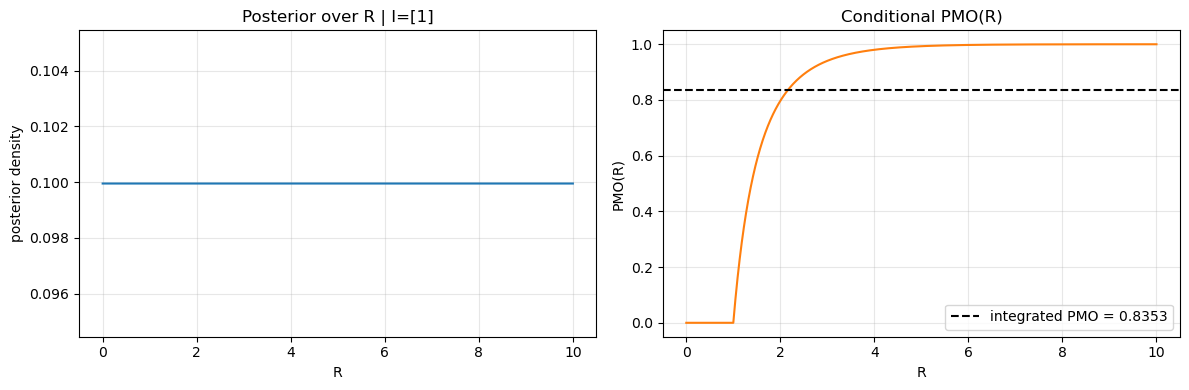

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(res["R_grid"], res["post"], color="tab:blue")
axes[0].set_xlabel("R"); axes[0].set_ylabel("posterior density")
axes[0].set_title(f"Posterior over R | I={res['I_seq']}")
axes[0].grid(alpha=0.3)

axes[1].plot(res["R_grid"], res["pmogivenR"], color="tab:orange")
axes[1].axhline(res["PMO"], ls="--", color="k", label=f"integrated PMO = {res['PMO']:.4f}")
axes[1].set_xlabel("R"); axes[1].set_ylabel("PMO(R)")
axes[1].set_title("Conditional PMO(R)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Trajectory matching

`trajectory_match_pmo` selects simulations whose first `k` weekly counts exactly
equal the observed counts and computes the empirical PMO.

In [30]:
def trajectory_match_pmo(observed_weeks, df, week_prefix="week_",
                         return_matches_df=False) -> Dict[str, Any]:
    """Match rows of `df` whose first k weekly counts == observed_weeks."""
    week_cols = week_cols_of(df, week_prefix)
    if not week_cols:
        raise ValueError(f"No columns starting with '{week_prefix}' found")

    k = len(observed_weeks)
    if k <= 0:
        raise ValueError("observed_weeks must contain at least one value")
    if k > len(week_cols):
        raise ValueError(f"observed_weeks length ({k}) > available weeks ({len(week_cols)})")

    obs_arr = np.asarray(observed_weeks, dtype=int)
    sim_firstk = df[week_cols[:k]].to_numpy(dtype=int)
    matches_mask = np.all(sim_firstk == obs_arr.reshape(1, -1), axis=1)

    matched_indices = list(np.nonzero(matches_mask)[0].tolist())
    n_matches = int(matches_mask.sum())

    n_major = 0
    pmo_fraction: Optional[float] = None
    matches_df = None
    if n_matches > 0:
        if "PMO" not in df.columns:
            raise ValueError("df has no 'PMO' column; cannot compute PMO fraction.")
        matches_df = df.loc[matches_mask].copy()
        pmo_vals = matches_df["PMO"].astype(int).to_numpy()
        n_major = int((pmo_vals == 1).sum())
        pmo_fraction = float(n_major) / float(n_matches)

    out: Dict[str, Any] = {"n_matches": n_matches, "n_major": n_major,
                           "pmo_fraction": pmo_fraction, "matched_indices": matched_indices}
    if return_matches_df:
        out["matches_df"] = matches_df
    return out


# quick check
_chk = trajectory_match_pmo([1, 2, 3], sim_df)
print(f"matches for [1,2,3]: {_chk['n_matches']} | empirical PMO = {_chk['pmo_fraction']}")

matches for [1,2,3]: 704 | empirical PMO = 0.9971590909090909


## 8. Matched-trajectory plot

Matched trajectories coloured by outcome (blue = major / PMO=1, gray = minor),
with the cutoff week marked. Operates on `sim_df`.

In [31]:
MATCH_SAMPLE_STRATEGY = "highest_peak"
BLUE = "tab:blue"
GRAY = "dimgray"
ALPHA = 0.6
LINEWIDTH = 1.0


def prepare_plot_data(matches_df, week_cols, max_plot, major_threshold):
    pmo_flags = matches_df["PMO"].astype(int).to_numpy()
    arr = matches_df[week_cols].to_numpy(dtype=float)
    if max_plot is not None and max_plot < arr.shape[0]:
        arr = arr[:max_plot, :].copy()
        pmo_flags = pmo_flags[:max_plot].copy()
    plotted = arr.shape[0]
    cumul = np.cumsum(arr, axis=1)
    reached = (cumul >= major_threshold).any(axis=1)
    hit_idx = np.argmax(cumul >= major_threshold, axis=1)
    n_weeks = arr.shape[1]
    return arr, pmo_flags, cumul, reached, hit_idx, n_weeks, plotted


def plot_matches(arr, pmo_flags, reached, hit_idx, n_weeks, plotted, n_matches,
                 n_total, pmo_fraction, major_threshold, observed, out_png, figsize):
    weeks = np.arange(1, n_weeks + 1)
    fig, ax = plt.subplots(figsize=figsize)

    for i, weekly in enumerate(arr):
        color = BLUE if pmo_flags[i] == 1 else GRAY
        if reached[i]:
            k = int(hit_idx[i])
            ax.plot(weeks[: k + 1], weekly[: k + 1], color=color, alpha=ALPHA, linewidth=LINEWIDTH)
        else:
            ax.plot(weeks, weekly, color=color, alpha=ALPHA, linewidth=LINEWIDTH)

    if reached.any():
        xs = weeks[hit_idx[reached]]
        ys = arr[reached, :][np.arange(xs.size), hit_idx[reached]]
        ax.scatter(xs, ys, color="red", s=20, zorder=3, label="cutoff")

    pmo_label = f"PMO (matched) = {pmo_fraction:.3f}" if pmo_fraction is not None else "PMO (matched) = NA"
    ax.plot([], [], color=BLUE, label="PMO = 1 (matched)")
    ax.plot([], [], color=GRAY, label="PMO = 0 (matched)")
    ax.plot([], [], " ", label=pmo_label)

    ax.set_xlim(1, n_weeks + 0.5)
    ax.set_xticks(np.arange(1, n_weeks + 1, 1))
    ax.xaxis.set_major_locator(MultipleLocator(1))
    if reached.any():
        ax.set_ylim(0, max(arr[reached, :].max(), 1) + 1)
    else:
        ax.set_ylim(0, max(arr.max(), 1) + 1)

    ax.set_xlabel("Week"); ax.set_ylabel("Cases per week")
    obs_str = ", ".join(str(x) for x in observed) if observed else "[]"
    ax.set_title(
        f"Matched trajectories (plotted {plotted} out of {n_matches}/{n_total}).\n"
        f"Initial Cases: {obs_str}  |  Cutoff: cumulative >= {major_threshold}\n"
        f"Strategy: {MATCH_SAMPLE_STRATEGY}")
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(which="major", color="0.85", linewidth=0.6, alpha=0.8)

    Path(out_png).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()


def run_plot_matches(df, observed, major_threshold=100, out_png="figs/matched_trajectories.png",
                     sample_strategy="highest_peak", sample_size=200, max_plot=200, figsize=(9, 6)):
    global MATCH_SAMPLE_STRATEGY
    MATCH_SAMPLE_STRATEGY = sample_strategy

    res = trajectory_match_pmo(observed, df, return_matches_df=True)
    if res["n_matches"] == 0:
        raise ValueError("No matching trajectories found.")
    matches_df = res["matches_df"]
    pmo_fraction = res["pmo_fraction"]
    n_total = len(df)
    week_cols = week_cols_of(matches_df)

    n_matches_total = len(matches_df)
    eff = sample_size if sample_size is not None else max_plot
    if eff is None or eff >= n_matches_total:
        sampled_df = matches_df.copy()
    else:
        sel_idx = np.unique(select_indices(matches_df, week_cols, strategy=sample_strategy,
                                           sample_size=eff, random_seed=42))
        sampled_df = matches_df.iloc[sel_idx].reset_index(drop=True)

    arr, pmo_flags, cumul, reached, hit_idx, n_weeks, plotted = prepare_plot_data(
        sampled_df, week_cols, max_plot=None, major_threshold=major_threshold)
    plot_matches(arr, pmo_flags, reached, hit_idx, n_weeks, plotted,
                 n_matches=n_matches_total, n_total=n_total, pmo_fraction=pmo_fraction,
                 major_threshold=major_threshold, observed=observed, out_png=out_png, figsize=figsize)
    print(f"Matched plot -> {out_png}  ({n_matches_total} matches, PMO={pmo_fraction:.4f})")
    return out_png

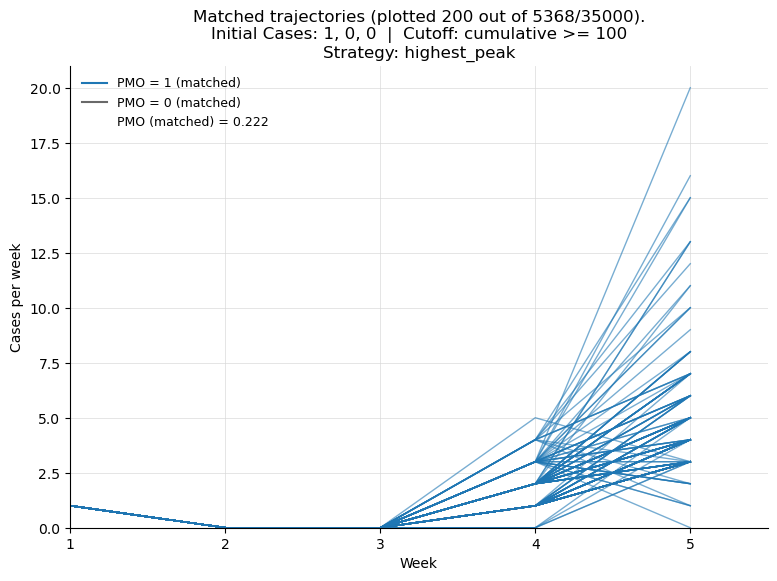

Matched plot -> figs/matched_trajectories.png  (5368 matches, PMO=0.2217)


'figs/matched_trajectories.png'

In [32]:
run_plot_matches(sim_df, observed=[1,0,0], sample_size=200,
                 major_threshold=100, sample_strategy="highest_peak")

## 9. Cumulative PMO across matched outbreaks

Running empirical PMO over sampled matched trajectories (`r = 1..R`) with a
random-shuffling confidence band, plus the analytic PMO overlaid. A full-index
variant maps the running PMO onto the full simulation-ID axis.

In [33]:
def compute_running_ci(pmo_flags, n_boot=500, ci=0.90, random_seed=None):
    """Pointwise CI band for running PMO via repeated shuffling of pmo_flags."""
    if pmo_flags is None or pmo_flags.size == 0:
        return np.array([]), np.array([])
    R = pmo_flags.size
    rng = np.random.default_rng(random_seed)
    runs = np.empty((max(1, int(n_boot)), R), dtype=float)
    for i in range(runs.shape[0]):
        perm_flags = pmo_flags[rng.permutation(R)]
        runs[i, :] = np.cumsum(perm_flags, dtype=float) / np.arange(1, R + 1, dtype=float)
    alpha = 1.0 - float(ci)
    lower = np.percentile(runs, 100.0 * (alpha / 2.0), axis=0)
    upper = np.percentile(runs, 100.0 * (1.0 - alpha / 2.0), axis=0)
    return lower, upper


def prepare_sample(matches_df, week_cols, sample_strategy, sample_size, random_seed=None):
    if sample_size is None or sample_size >= len(matches_df):
        return matches_df.copy().reset_index(drop=True)
    sel_idx = np.array(select_indices(matches_df, week_cols, strategy=sample_strategy,
                                      sample_size=sample_size, random_seed=random_seed), dtype=int)
    return matches_df.iloc[sel_idx].reset_index(drop=True)


def plot_pmo_vs_r(pmo_r, out_png, figsize, observed, sample_strategy, sort_by,
                  analytic_pmo=None, pmo_flags=None, show_ci=True, ci=0.90,
                  n_boot=500, ci_random_seed=42) -> str:
    AZURE = "xkcd:azure"; ORANGE = "xkcd:bright orange"
    R = int(pmo_r.size)
    rs = np.arange(1, R + 1)

    lower = upper = None
    if show_ci and (pmo_flags is not None) and (pmo_flags.size == R) and R > 0:
        lower, upper = compute_running_ci(pmo_flags, n_boot=n_boot, ci=ci, random_seed=ci_random_seed)

    fig, ax = plt.subplots(figsize=figsize)
    overall = float(pmo_r[-1]) if R > 0 else float("nan")

    if lower is not None and lower.size == R:
        ax.fill_between(rs, lower, upper, alpha=0.18, color=AZURE, zorder=1,
                        label=f"{int(ci*100)}% band (random shuffling)")
    if R > 0:
        idx = np.linspace(0, R - 1, min(50, R), dtype=int)
        ax.scatter(rs[idx], pmo_r[idx], s=30, c=AZURE, edgecolors="none", alpha=0.5, zorder=2)
        ax.plot(rs, pmo_r, linewidth=2.0, alpha=0.95, color=AZURE,
                label=f"Running PMO = {overall:.5f}", zorder=3)
    if analytic_pmo is not None and np.isfinite(analytic_pmo):
        ax.axhline(analytic_pmo, linestyle="--", linewidth=1.4, color=ORANGE,
                   label=f"Analytic PMO = {analytic_pmo:.5f}", zorder=5)

    ax.set_xlabel("Sampled matched trajectory index"); ax.set_ylabel("Cumulative PMO fraction")
    obs_str = ", ".join(str(x) for x in observed) if observed else "[]"
    ax.set_title(f"Cumulative PMO across matched outbreaks\n{R} outbreaks with initial cases {obs_str}\n"
                 f"Sampling: {sample_strategy} | sort_by: {sort_by}")
    ax.set_xlim(1, max(1, R)); ax.set_ylim(-0.01, 1.02)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25, which="major", linestyle="--")
    ax.legend(frameon=False, fontsize=9, loc="upper right")
    Path(out_png).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    return out_png


def plot_pmo_over_full_index(sel_sim_ids, sel_pmo, N_total, out_png, figsize,
                             analytic_single=None, observed=None, n_matches=None,
                             show_ci=True, ci=0.90, n_boot=500, ci_random_seed=42, max_points=5000):
    AZURE = "xkcd:azure"; ORANGE = "xkcd:bright orange"
    m = sel_pmo.size
    cum = np.cumsum(sel_pmo) / np.arange(1, m + 1)
    events_df = pd.DataFrame({"sim_id": sel_sim_ids.astype(int), "PMO": sel_pmo.astype(int),
                              "event_order": np.arange(1, m + 1), "cum_pmo": cum})
    dense_x = (np.arange(1, N_total + 1, dtype=float) if N_total <= max_points
               else np.linspace(1.0, float(N_total), num=max_points))
    final_pmo = float(cum[-1])
    dense_y = np.interp(dense_x, sel_sim_ids.astype(float), cum, left=0.0, right=final_pmo)

    dense_lo = dense_hi = None
    if show_ci and m > 0:
        lo, hi = compute_running_ci(sel_pmo.astype(int), n_boot=n_boot, ci=ci, random_seed=ci_random_seed)
        dense_lo = np.interp(dense_x, sel_sim_ids.astype(float), lo, left=0.0, right=final_pmo)
        dense_hi = np.interp(dense_x, sel_sim_ids.astype(float), hi, left=0.0, right=final_pmo)

    fig, ax = plt.subplots(figsize=figsize)
    if dense_lo is not None:
        ax.fill_between(dense_x, dense_lo, dense_hi, alpha=0.18, color=AZURE, zorder=1,
                        label=f"{int(ci*100)}% band (random shuffling)")
    ax.plot(dense_x, dense_y, linewidth=2.0, alpha=0.95, color=AZURE,
            label=f"Running PMO = {final_pmo:.5f}", zorder=2)
    if analytic_single is not None and np.isfinite(analytic_single):
        ax.axhline(analytic_single, linestyle="--", linewidth=1.5, color=ORANGE,
                   label=f"Analytic PMO = {analytic_single:.3f}", zorder=5)
    ax.set_xlim(1, float(N_total) + 0.5); ax.set_ylim(-0.01, 1.05)
    ax.set_xlabel("Simulation ID (1..N_total)"); ax.set_ylabel("Cumulative PMO fraction")
    obs_str = ", ".join(str(x) for x in (observed or []))
    ax.set_title(f"Cumulative PMO across matched outbreaks over full simulation\n"
                 f"{int(n_matches or m)} outbreaks with initial cases {obs_str}")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25, which="major", linestyle="--")
    ax.legend(frameon=False, fontsize=9, loc="upper right")
    out_full = Path(out_png).with_name(Path(out_png).stem + "_full_index.png")
    Path(out_full).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_full, dpi=200, bbox_inches="tight")
    plt.show()
    return str(out_full), events_df


def run_pmo_vs_r(df, observed, out_png="figs/pmo_vs_r.png", sample_strategy="random",
                 sample_size=200, sort_by="sample_order", figsize=(8, 5), random_seed=42,
                 full_index=False, show_ci=True, ci=0.90, n_boot=500, ci_random_seed=42):
    res = trajectory_match_pmo(observed, df, return_matches_df=True)
    if res["n_matches"] == 0:
        raise ValueError("No matching trajectories found.")
    matches_df = res["matches_df"].copy()
    week_cols = week_cols_of(matches_df)

    sampled_df = prepare_sample(matches_df, week_cols, sample_strategy, sample_size, random_seed)

    if sort_by != "sample_order":
        keymap = {"by_cumulative": sampled_df[week_cols].sum(axis=1),
                  "by_peak": sampled_df[week_cols].max(axis=1),
                  "by_R": sampled_df.get("R_draw"),
                  "by_PMO": sampled_df["PMO"].astype(int)}
        key = keymap.get(sort_by)
        if key is not None:
            sampled_df = (sampled_df.assign(_k=key).sort_values("_k", ascending=False)
                                    .drop(columns="_k").reset_index(drop=True))

    # analytic reference (float R range straight from the data)
    R_min_val = float(df["R_draw"].min()); R_max_val = float(df["R_draw"].max())
    try:
        analytic_pmo = float(compute_pmo_from_string(list(observed), nR=2001,
                                                     R_min=R_min_val, R_max=R_max_val)["PMO"])
    except Exception:
        analytic_pmo = float("nan")

    if not full_index:
        flags = sampled_df["PMO"].astype(int).to_numpy()
        pmo_r = np.cumsum(flags) / np.arange(1, flags.size + 1)
        out = plot_pmo_vs_r(pmo_r, out_png, figsize, observed, sample_strategy, sort_by,
                            analytic_pmo=analytic_pmo, pmo_flags=flags, show_ci=show_ci,
                            ci=ci, n_boot=n_boot, ci_random_seed=ci_random_seed)
        return out, None

    N_total = len(df)
    sim_ids = sampled_df["sim_id"].astype(int).to_numpy()
    order = np.argsort(sim_ids)
    sel_sim_ids = sim_ids[order]
    sel_pmo = sampled_df["PMO"].astype(int).to_numpy()[order]
    out, events_df = plot_pmo_over_full_index(sel_sim_ids, sel_pmo, N_total, out_png, figsize,
                                              analytic_single=analytic_pmo, observed=observed,
                                              n_matches=sel_sim_ids.size, show_ci=show_ci, ci=ci,
                                              n_boot=n_boot, ci_random_seed=ci_random_seed)
    return out, events_df

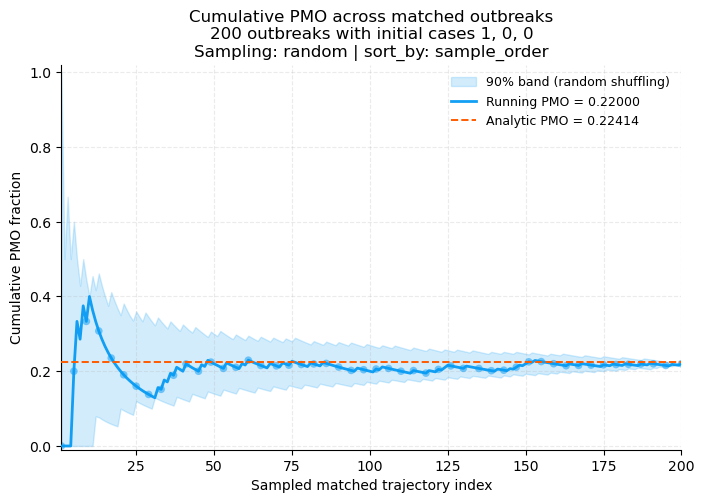

PMO vs r plot -> figs/pmo_vs_r.png


In [35]:
out, _ = run_pmo_vs_r(sim_df, observed=[1, 0,0], sample_strategy="random",
                      sample_size=200, full_index=False, show_ci=True, ci=0.9)
print("PMO vs r plot ->", out)

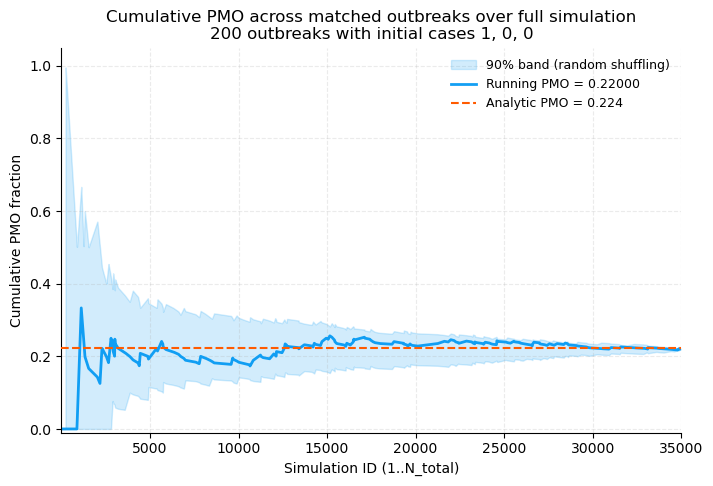

PMO vs r (full index) plot -> figs/pmo_vs_r_full_index.png


,sim_id,PMO,event_order,cum_pmo
0,233,0,1,0.000000
1,878,0,2,0.000000
2,1121,1,3,0.333333
3,1257,0,4,0.250000
4,1324,0,5,0.200000


In [36]:
out_full, events_df = run_pmo_vs_r(sim_df, observed=[1,0,0], sample_strategy="random",
                                  sample_size=200, full_index=True, show_ci=True, ci=0.9)
print("PMO vs r (full index) plot ->", out_full)
events_df.head()

## 10. Machine-learning PMO estimator

The ML approach learns `PMO` from the first three weekly counts
(`week_1, week_2, week_3`). To study convergence we **train** RF and GB on
growing subsets of `sim_df` (500 → up to N) and watch the predicted probability
approach the analytic value for a few reference samples.

**Self-contained:** the models are trained here, in memory (a dict keyed by
`(size, model_name)`); nothing is loaded from committed `.pkl` files. The full
sweep takes ~45 s. Set `SAVE_MODELS = True` to also persist them to disk.

In [37]:
# reference samples + their analytic PMO (computed live over the data's R range)
ML_SAMPLES = [(1, 2, 0), (1, 1, 0), (1, 0, 0), (1, 2, 1), (1, 3, 1), (1, 0, 1), (1, 5, 3)]
ML_R_MIN = float(sim_df["R_draw"].min())
ML_R_MAX = float(sim_df["R_draw"].max())

analytic_ref = {s: float(compute_pmo_from_string(list(s), nR=2001,
                                                 R_min=ML_R_MIN, R_max=ML_R_MAX)["PMO"])
                for s in ML_SAMPLES}

# training-data sizes: 500, 1000, ..., clamped to the number of simulations
N = len(sim_df)
data_sizes = [s for s in (500 * i for i in range(1, 70)) if s <= N]
print(f"{len(data_sizes)} data sizes: {data_sizes[0]} ... {data_sizes[-1]} (N={N})")
print("analytic reference PMO per sample:")
for s, v in analytic_ref.items():
    print(f"  {s}: {v:.5f}")

69 data sizes: 500 ... 34500 (N=35000)
analytic reference PMO per sample:
  (1, 2, 0): 0.71617
  (1, 1, 0): 0.53455
  (1, 0, 0): 0.22414
  (1, 2, 1): 0.90805
  (1, 3, 1): 0.94251
  (1, 0, 1): 0.74969
  (1, 5, 3): 0.99822


### 10a. Train RF + GB across data sizes

The scaler is fit on each subset.

In [38]:
FEATURES = ["week_1", "week_2", "week_3"]


def train_ml_models(df, data_sizes, features=FEATURES, target="PMO", verbose=True):
    """Train RF + GB on growing prefixes of df. Returns {(size, name): (model, scaler)}."""
    X = df[features].astype(float).to_numpy()
    y = df[target].astype(int).to_numpy()
    trained: Dict[Tuple[int, str], tuple] = {}
    t0 = time.perf_counter()
    for size in data_sizes:
        Xs, ys = X[:size], y[:size]
        scaler = StandardScaler().fit(Xs)
        Xss = scaler.transform(Xs)
        for name, model in (
            ("RF", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
            ("GB", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)),
        ):
            model.fit(Xss, ys)
            trained[(size, name)] = (model, scaler)
    if verbose:
        print(f"Trained {len(trained)} models ({len(data_sizes)} sizes x 2) "
              f"in {time.perf_counter() - t0:.1f}s")
    return trained


def save_trained_models(trained, features=FEATURES, model_dir="src/outbreak_probabilities/machine_learning/Model_SIM"):
    """Optional: persist trained models to disk in the runner.py layout."""
    import joblib
    from datetime import datetime
    model_dir = Path(model_dir); model_dir.mkdir(parents=True, exist_ok=True)
    for (size, name), (model, scaler) in trained.items():
        stem = f"ML_SIM_{size}_{name}"
        joblib.dump(model, model_dir / f"{stem}.pkl", compress=3)
        joblib.dump(scaler, model_dir / f"{stem}_scaler.pkl", compress=3)
        meta = {"model_name": name, "feature_names": list(features), "data_size": size,
                "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
        (model_dir / f"{stem}.json").write_text(json.dumps(meta, indent=4))
    print("Saved", len(trained), "models to", model_dir)


trained_models = train_ml_models(sim_df, data_sizes)

SAVE_MODELS = False
if SAVE_MODELS:
    save_trained_models(trained_models)

Trained 138 models (69 sizes x 2) in 45.5s


### 10b. Prediction helper

In [ ]:
def predict_pmo(trained, model_name, weeks, size=None, threshold=0.5):
    """Predict PMO for a (week_1, week_2, week_3) tuple using a trained model."""
    if size is None:
        size = max(s for (s, n) in trained if n == model_name)
    model, scaler = trained[(size, model_name)]
    arr = np.asarray(weeks, dtype=float).reshape(1, -1)
    proba = float(model.predict_proba(scaler.transform(arr))[0][1])
    return {"model": model_name, "size": size, "probability": proba,
            "PMO": int(proba >= threshold), "label": "major" if proba >= threshold else "minor"}


print("GB on (1,2,0):", predict_pmo(trained_models, "GB", (1, 2, 0)))
print("RF on (1,2,0):", predict_pmo(trained_models, "RF", (1, 2, 0)))
print("analytic (1,2,0):", round(analytic_ref[(1, 2, 0)], 5))

GB on (1,2,0): {'model': 'GB', 'size': 34500, 'probability': 0.722504220654845, 'PMO': 1, 'label': 'major'}
RF on (1,2,0): {'model': 'RF', 'size': 34500, 'probability': 0.7211994945715814, 'PMO': 1, 'label': 'major'}
analytic (1,2,0): 0.71617


### 10c. Convergence plots

For each reference sample, plot the RF and GB predicted PMO against training-data
size, with the analytic value (and a ±5% band) for reference.

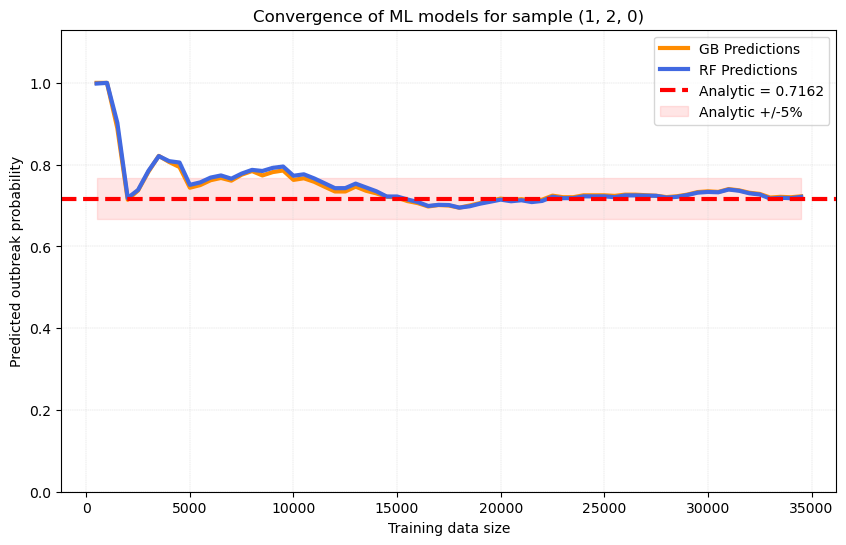

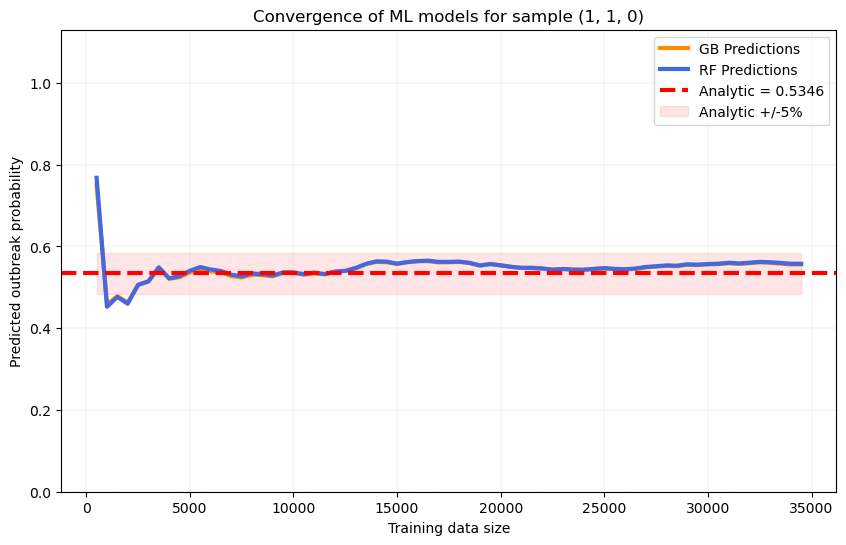

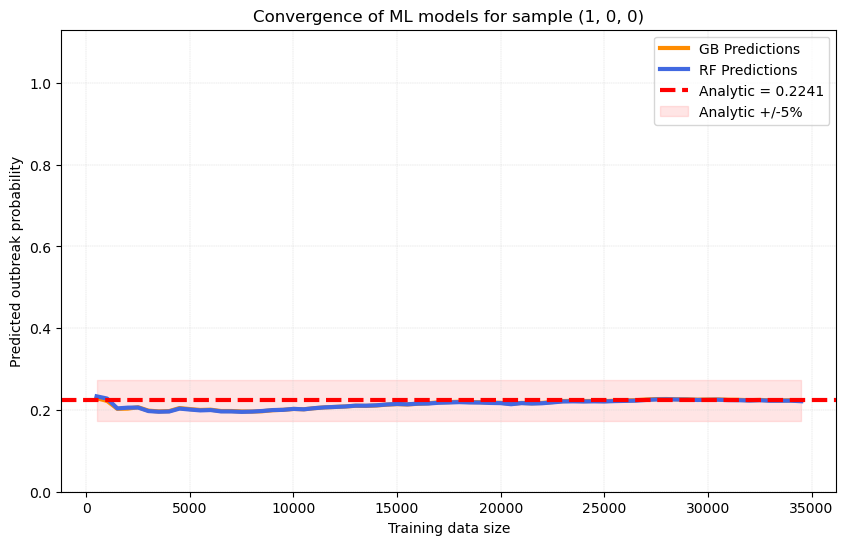

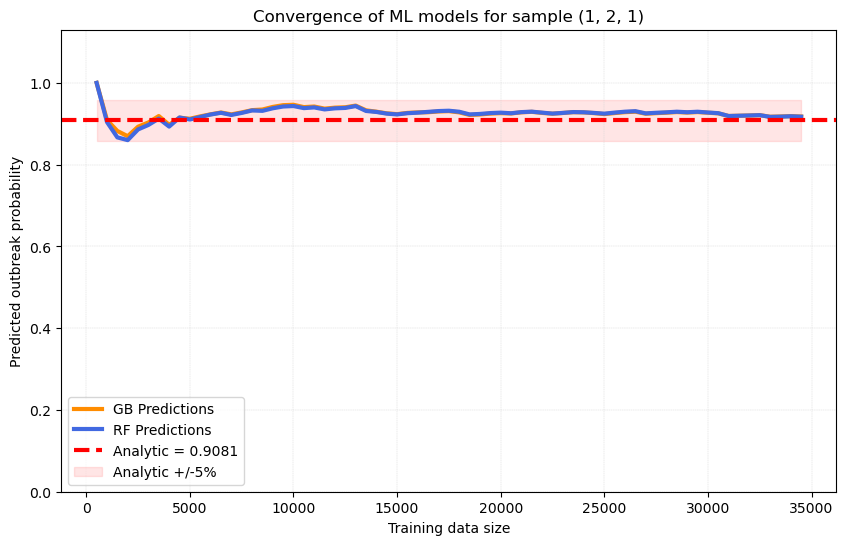

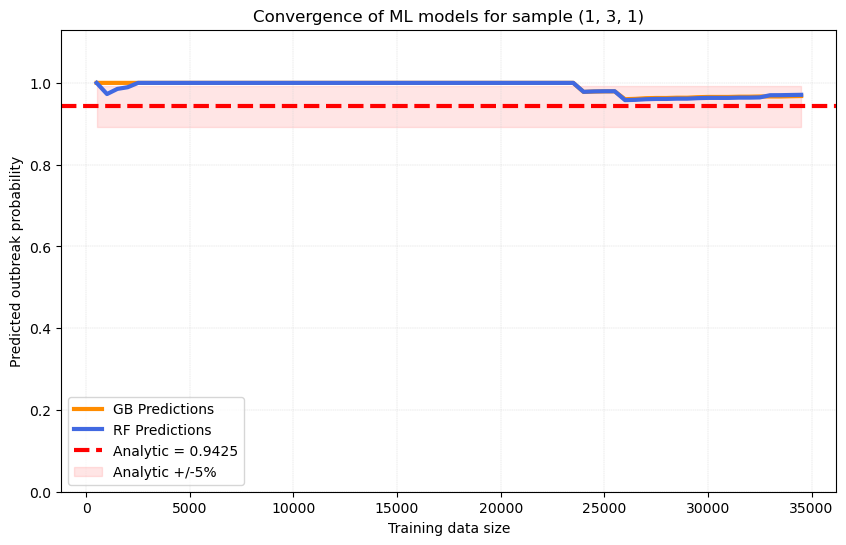

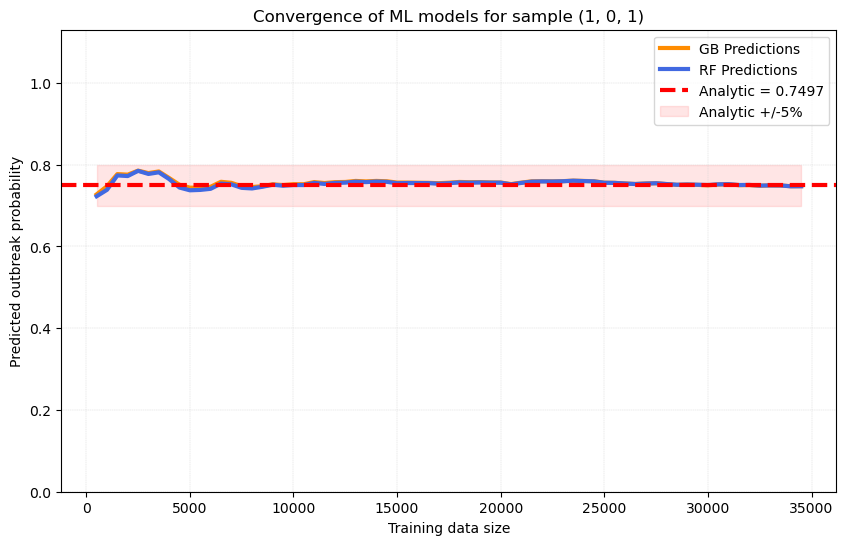

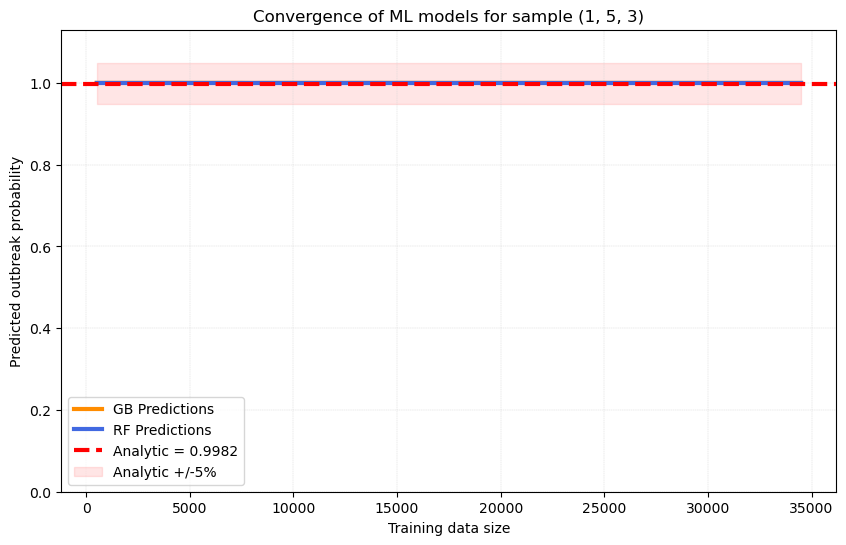

In [39]:
def ml_convergence_predictions(trained, data_sizes, samples, model_names=("GB", "RF")):
    """{sample: {model_name: [pred over data_sizes]}} from in-memory trained models."""
    results = {s: {m: [] for m in model_names} for s in samples}
    for m in model_names:
        for size in data_sizes:
            model, scaler = trained[(size, m)]
            for s in samples:
                arr = np.asarray(s, dtype=float).reshape(1, -1)
                results[s][m].append(float(model.predict_proba(scaler.transform(arr))[0][1]))
    return results


def plot_ml_convergence(results, data_sizes, analytic_ref, samples, save_dir="figs/ml_convergence",
                        band=0.05, model_colors=(("GB", "darkorange"), ("RF", "royalblue"))):
    save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
    for sample in samples:
        plt.figure(figsize=(10, 6))
        for name, color in model_colors:
            if results[sample].get(name):
                plt.plot(data_sizes, results[sample][name], label=f"{name} Predictions",
                         color=color, linewidth=3)
        sol = analytic_ref[sample]
        plt.axhline(sol, color="red", linestyle="--", linewidth=3, label=f"Analytic = {sol:.4f}")
        if band:
            plt.fill_between(data_sizes, sol - band, sol + band, color="red", alpha=0.1,
                             label=f"Analytic +/-{int(band*100)}%")
        plt.title(f"Convergence of ML models for sample {sample}")
        plt.xlabel("Training data size"); plt.ylabel("Predicted outbreak probability")
        plt.ylim(0, 1.13); plt.legend(); plt.grid(color="lightgrey", linestyle="--", linewidth=0.3)
        plt.savefig(save_dir / f"convergence_{sample[0]}_{sample[1]}_{sample[2]}.png", dpi=150)
        plt.show()


conv_results = ml_convergence_predictions(trained_models, data_sizes, ML_SAMPLES)
plot_ml_convergence(conv_results, data_sizes, analytic_ref, ML_SAMPLES)

## 11. Comparison: ML vs trajectory-matching vs analytic

For each initial sample, overlay all three PMO estimators on one log-x axis:

- **ML (GB & RF):** predicted PMO vs training-data size (in-memory models).
- **Analytic:** horizontal reference (±5% band).
- **Trajectory-matching:** running cumulative PMO over matched simulations,
  mapped onto the ML training-size axis (sim IDs `1..max_size` → `min..max`).

Everything uses `sim_df` and the in-memory `trained_models` — no disk loads.

In [40]:
COL_GB = "xkcd:asparagus"; COL_RF = "royalblue"
COL_PMO = "xkcd:darkblue"; COL_ANALYTIC = "red"


def ml_curves_for_sample(trained, sample, data_sizes, model_names=("GB", "RF")):
    arr = np.asarray(sample, dtype=float).reshape(1, -1)
    out = {m: [] for m in model_names}
    for size in data_sizes:
        for m in model_names:
            model, scaler = trained[(size, m)]
            out[m].append(float(model.predict_proba(scaler.transform(arr))[0][1]))
    return out


def make_combined_plot(initial_sample, df, trained, data_sizes, model_names=("GB", "RF"),
                       out_png=None, figsize=(11, 6)):
    out_png = out_png or f"figs/comparison_initial_{'_'.join(map(str, initial_sample))}.png"
    sizes = np.array(data_sizes, dtype=int)
    x_min, x_max = float(sizes.min()), float(sizes.max())
    max_S = int(sizes.max())

    # ML predictions
    ml = ml_curves_for_sample(trained, initial_sample, sizes.tolist(), model_names)

    # trajectory matches from sim_df
    res = trajectory_match_pmo(initial_sample, df, return_matches_df=True)
    if res["n_matches"] == 0:
        raise ValueError(f"No matches for {initial_sample}")
    matched = res["matches_df"].sort_values("sim_id").reset_index(drop=True)
    matched = matched[matched["sim_id"].astype(int) <= max_S].reset_index(drop=True)

    # analytic (float R range)
    Rmin = float(df["R_draw"].min()); Rmax = float(df["R_draw"].max())
    analytic_val = float(compute_pmo_from_string(list(initial_sample), nR=2001,
                                                 R_min=Rmin, R_max=Rmax)["PMO"])

    # running PMO step curve mapped onto ML x-space
    sim_ids = matched["sim_id"].astype(float).to_numpy()
    cum = np.cumsum(matched["PMO"].astype(int).to_numpy()) / np.arange(1, len(matched) + 1)
    mapped_x = np.interp(sim_ids, [1.0, float(max_S)], [x_min, x_max])
    xs, ys = [x_min], [0.0]
    for mx, nv in zip(mapped_x, cum):
        xs += [mx, mx]; ys += [ys[-1], nv]
    xs.append(x_max); ys.append(float(cum[-1]))
    xs, ys = np.array(xs), np.array(ys)

    fig, ax = plt.subplots(figsize=figsize)
    for m, col in zip(model_names, (COL_GB, COL_RF)):
        y = np.array(ml[m]); ax.plot(sizes, y, color=col, linewidth=2.5,
                                     label=f"{m} predicted PMO = {y[-1]:.5f}")
    ax.axhline(analytic_val, color=COL_ANALYTIC, linestyle="--", linewidth=2.0,
               label=f"Analytic PMO = {analytic_val:.5f}")
    ax.fill_between(sizes, max(0.0, analytic_val - 0.05), min(1.0, analytic_val + 0.05),
                    color=COL_ANALYTIC, alpha=0.08)
    ax.plot(xs[2:], ys[2:], color=COL_PMO, linewidth=1.8, drawstyle="steps-post", alpha=0.8,
            label=f"Trajectory-matching PMO = {ys[-1]:.5f}")
    ax.scatter(mapped_x, cum, s=5, color=COL_PMO, alpha=0.2, zorder=1)

    ax.set_xlabel("Number of simulations (log scale)"); ax.set_ylabel("PMO")
    ax.set_title("PMO comparison: machine learning (RF, GB) vs trajectory matching\n"
                 f"Initial cases {tuple(initial_sample)}")
    ax.set_xlim(x_min, x_max); ax.set_xscale("log"); ax.set_ylim(-0.02, 1.02)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25, which="major", linestyle="--")
    ax.legend(frameon=False, fontsize=9, loc="upper right")
    Path(out_png).parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout(); fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"{tuple(initial_sample)}: matches={len(matched)} analytic={analytic_val:.5f} -> {out_png}")
    return out_png

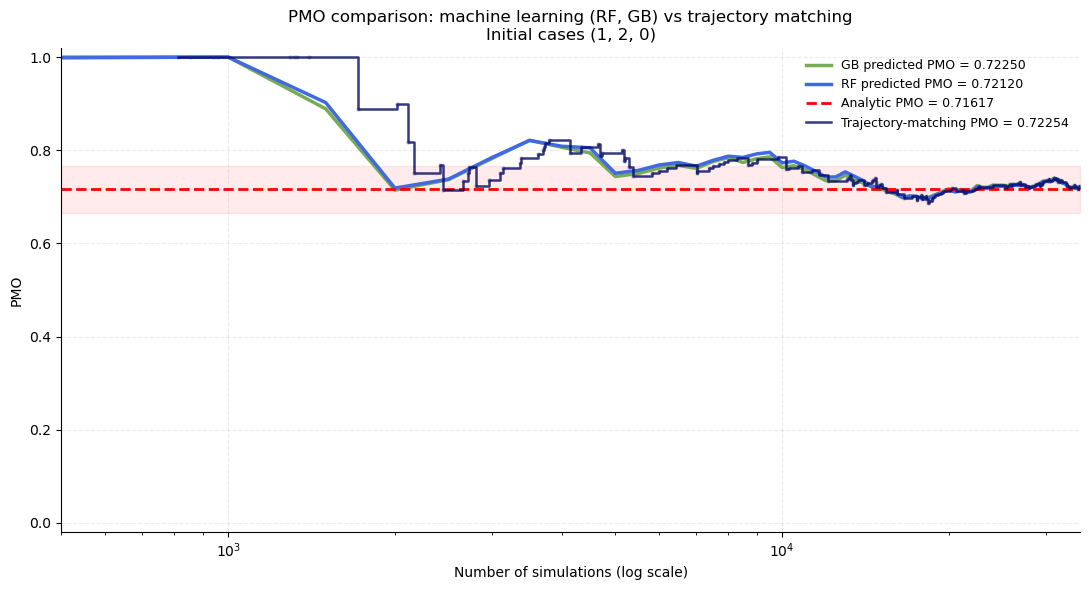

(1, 2, 0): matches=173 analytic=0.71617 -> figs/comparison_initial_1_2_0.png


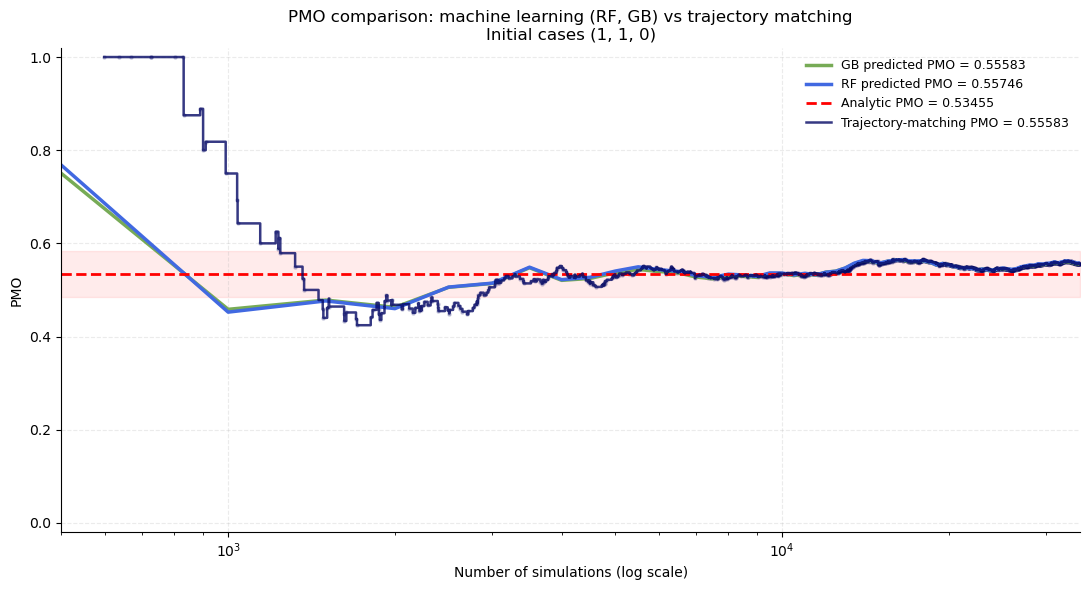

(1, 1, 0): matches=1236 analytic=0.53455 -> figs/comparison_initial_1_1_0.png


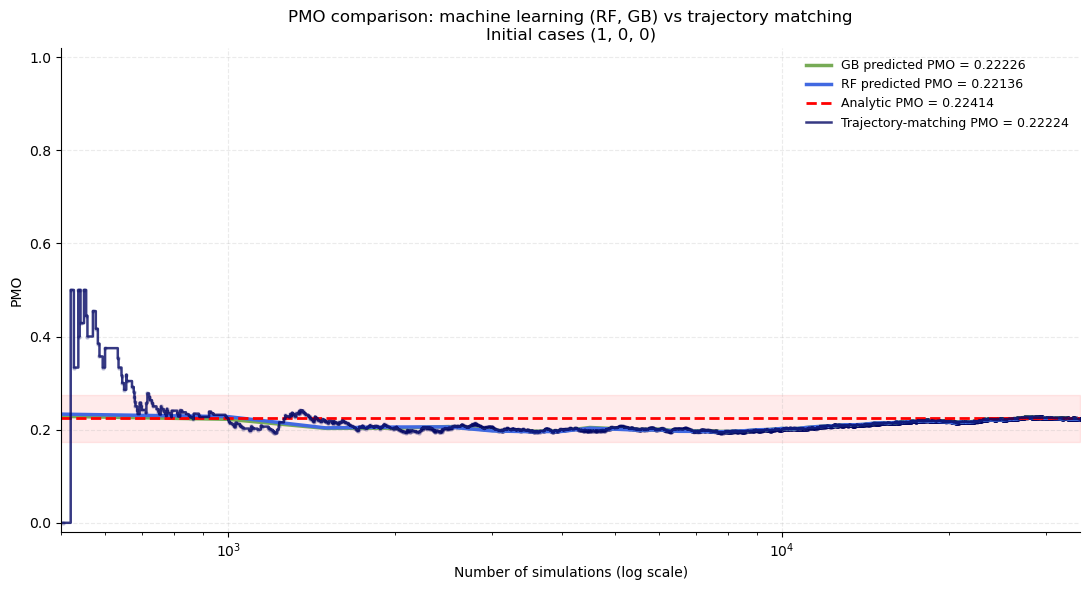

(1, 0, 0): matches=5296 analytic=0.22414 -> figs/comparison_initial_1_0_0.png


In [ ]:
for INITIAL in [(1, 2, 0), (1, 1, 0), (1, 0, 0)]:
    make_combined_plot(INITIAL, sim_df, trained_models, data_sizes)